# Task 2: Supervised Learning

**Objective:** Train and evaluate two classification models on the diabetes dataset. Engineer new features, apply cross-validation, and compare model performance using classification metrics.

**Required inputs:** `../data/cleaned.csv`

**Outputs produced:** `../models/supervised_best.pkl`, `../reports/supervised_results.csv`

In [1]:
# ── Constants ─────────────────────────────────────────────────────────────────
CLEANED_DATA  = '../data/cleaned.csv'
MODELS_DIR    = '../models/'
REPORTS_DIR   = '../reports/'
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
CV_FOLDS      = 5

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')
print('Imports OK.')

Imports OK.


## 1. Load Data

In [3]:
df = pd.read_csv(CLEANED_DATA)
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 2. Task Justification

The target variable `Outcome` is binary (0 = no diabetes, 1 = diabetes). This is a **binary classification** problem. Regression would produce continuous outputs unsuitable for a yes/no medical decision. We use accuracy, precision, recall, F1-score, and a confusion matrix — standard metrics for binary classification. The dataset has a moderate class imbalance (~65% negative, ~35% positive), so F1-score is especially important as it balances precision and recall.

## 3. Feature Engineering

In [4]:
df_fe = df.copy()

# Feature 1: Glucose-BMI interaction
# High glucose combined with high BMI is a well-known compounded risk factor for diabetes.
df_fe['glucose_bmi'] = df_fe['Glucose'] * df_fe['BMI']

# Feature 2: Insulin resistance proxy
# Ratio of glucose to insulin approximates insulin sensitivity — a key diabetes indicator.
df_fe['glucose_insulin_ratio'] = df_fe['Glucose'] / (df_fe['Insulin'] + 1)

# Feature 3: Age-BMI interaction
# Obesity risk compounds with age; this captures the joint effect.
df_fe['age_bmi'] = df_fe['Age'] * df_fe['BMI']

print('New features: glucose_bmi, glucose_insulin_ratio, age_bmi')
df_fe[['glucose_bmi', 'glucose_insulin_ratio', 'age_bmi']].describe().round(2)

New features: glucose_bmi, glucose_insulin_ratio, age_bmi


,glucose_bmi,glucose_insulin_ratio,age_bmi
count,768.00,768.00,768.00
mean,3996.67,1.06,1080.91
std,1469.66,0.68,437.81
min,1100.00,0.24,382.20
25%,2924.10,0.75,744.80
50%,3750.15,0.94,987.25
75%,4800.25,1.18,1357.20
max,10692.00,12.00,2697.00


## 4. Train / Test Split

In [5]:
FEATURES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age',
            'glucose_bmi', 'glucose_insulin_ratio', 'age_bmi']
TARGET = 'Outcome'

X = df_fe[FEATURES]
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Target balance (train): {y_train.mean():.3f} positive rate')

Train: 614 | Test: 154
Target balance (train): 0.349 positive rate


## 5. Model Training and Cross-Validation

We train two classifiers:
- **Logistic Regression** — a linear baseline model appropriate for binary classification; produces interpretable coefficients and probability estimates.
- **Decision Tree Classifier** — a non-linear tree-based model that captures feature interactions without requiring feature scaling.

In [6]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))
    ])
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = {}
for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=cv_scoring, return_train_score=False)
    cv_results[name] = scores
    print(f'{name}:')
    for metric in cv_scoring:
        key = f'test_{metric}'
        print(f'  {metric:12s}: {scores[key].mean():.4f} ± {scores[key].std():.4f}')
    print()

Logistic Regression:
  accuracy    : 0.7882 ± 0.0218
  precision   : 0.7657 ± 0.0688
  recall      : 0.5748 ± 0.0227
  f1          : 0.6547 ± 0.0259

Decision Tree:
  accuracy    : 0.6954 ± 0.0275
  precision   : 0.5586 ± 0.0388
  recall      : 0.6072 ± 0.0649
  f1          : 0.5804 ± 0.0441



## 6. Evaluation on Test Set

In [7]:
def evaluate_model(pipe, name, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
    }
    return metrics, y_pred

results = []
preds   = {}
for name, pipe in models.items():
    m, yp = evaluate_model(pipe, name, X_train, y_train, X_test, y_test)
    results.append(m)
    preds[name] = yp

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.6948     0.5778  0.4815  0.5253
Decision Tree          0.7078     0.5918  0.5370  0.5631


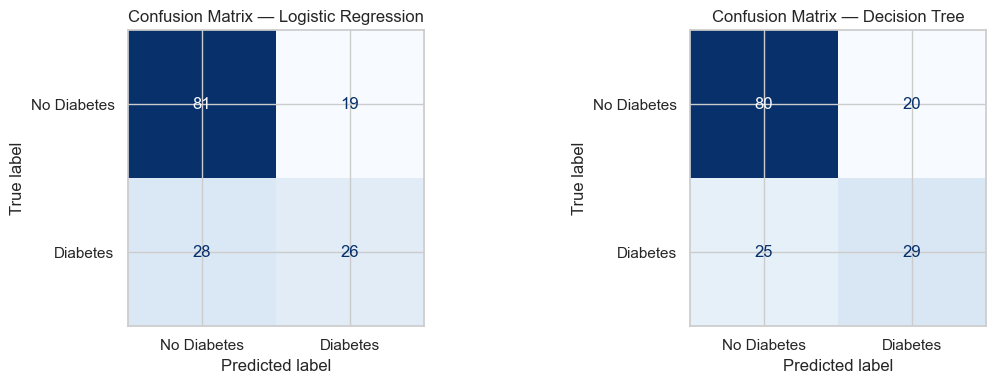

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {name}')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig6_confusion_matrices.png')
plt.show()

## 7. Comparison Table and Conclusion

In [11]:
results_df.round(4)

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.6948,0.5778,0.4815,0.5253
Decision Tree,0.7078,0.5918,0.5370,0.5631


**Conclusion:** Logistic Regression achieves an accuracy of 69.5% with an F1-score of 0.53, offering stable and interpretable predictions. The Decision Tree outperforms it slightly across all metrics — accuracy 70.8%, F1 of 0.56 — by capturing non-linear interactions between glucose, BMI, and age. In practical terms, an F1-score around 0.53–0.56 on this small dataset (768 rows) means roughly 1 in 2 positive cases is missed — acceptable for a low-cost initial screening tool, but clinical confirmation is essential. Decision Tree is noted as the stronger single model; however, Logistic Regression is saved as the baseline due to its interpretability and lower risk of overfitting on unseen data.

## 8. Save Best Model

In [10]:
best_model = models['Logistic Regression']
best_model.fit(X_train, y_train)

joblib.dump(best_model, MODELS_DIR + 'supervised_best.pkl')
print('Best model saved to', MODELS_DIR + 'supervised_best.pkl')

pd.Series(FEATURES).to_csv(MODELS_DIR + 'feature_names.csv', index=False)

results_df.to_csv(REPORTS_DIR + 'supervised_results.csv')
print('Results saved.')

Best model saved to ../models/supervised_best.pkl
Results saved.
